# Смена директории


In [57]:
%cd ..

/Users/macbook


# Импорт библиотек


In [ ]:
import logging
import warnings
import time


import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import yaml
import joblib
import shap
import optuna
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.neural_network import MLPClassifier
from category_encoders import CatBoostEncoder



from utils.dev_utils import get_pool
from utils.pipeline_utils import CustomPreprocessor
from utils.metrics import MetricCalculator, metric_funcs
from utils.style.styler import style_metrics
from utils.style.html_output import print_multiple_html
from utils.plot_utils import plot_gini_by_period_styled, plot_roc_by_masks

In [3]:
from keras.models import Sequential
from keras.layers import Dense, Dropout
import keras as kr

In [4]:
logging.getLogger().setLevel(logging.WARNING)
warnings.filterwarnings('ignore')
sns.set_palette('bright')


pd.options.display.float_format = "{:.2f}".format
pd.options.display.max_rows = 100
pd.options.display.max_columns = 100

In [5]:
%load_ext autoreload
%autoreload 2
%aimport utils.plot_utils
%aimport utils.eda_utils
%aimport utils.style_utils
%aimport utils.psi
%aimport utils.style.styler

# Входные данные


## Загрузка данных


In [6]:
data = pd.read_parquet('./data/processed/data.pqt')

data.shape

(1097231, 633)

## Валидные переменные


In [7]:
path = r'./docs/valid_features.xlsx'
valid_features_data = pd.read_excel(path, index_col=False)

## Конфиги/константы


In [8]:
TARGET = 'target'
DATE_MONTH = 'date_month'
DATE_QUARTAL = 'date_quartal'

FEATURES = valid_features_data.loc[(
    valid_features_data['valid_flag'] == 1)]['attribute'].values
CAT_FEATURES = sorted(set(FEATURES) & set(
    data.select_dtypes(include=["object", "category"]).columns))
NUM_FEATURES = sorted(set(FEATURES) & set(
    data.select_dtypes(include=["number"]).columns))

TRAIN_MASK = (data['sample_type'] == 'TRAIN')
TEST_MASK = (data['sample_type'] == 'TEST')
OOT_MASK = (data['sample_type'] == 'OOT')

DEV_MASK = (data['competition_sample_type'] == 'TRAIN')

In [9]:
print_multiple_html(
    ('Кол-во переменных: ', len(FEATURES)),
    ('Кол-во категориальных переменных: ', len(CAT_FEATURES))
)

In [10]:
metr_funcs = {
    'roc_auc': metric_funcs.roc_auc_score_nan,
    'gini': metric_funcs.gini_score_nan,
    'precision': metric_funcs.precision,
    'recall': metric_funcs.recall
}

stats_funcs = {
    'obs_cnt': lambda y_true, data: len(y_true),
    'target_cnt': lambda y_true, data: sum(y_true),
    'DR': lambda y_true, data: sum(y_true) / len(y_true)
}

# Класс для расчета метрик
metr_calc = MetricCalculator(metr_funcs=metr_funcs, stats_funcs=stats_funcs)


STYLE_CONFIG = {
    'percent_cols': ['gini', 'roc_auc', 'DR', 'precision', 'recall'],
    'int_cols': ['obs_cnt', 'target_cnt'],
    'gradient_cols': ['gini', 'roc_auc', 'precision', 'recall'],
    'gradient_cmap': 'RdYlGn',
}

# Словарь для сохранения времени обучения моделей
train_timing = {}

In [11]:
def metrics_split(data, group_cols, metr_calc, pred_cols=['lg_model_preds'], target='target', asc=True):
    """Упрощенный интерфес для расчета метрик"""

    metr_split = metr_calc.calculate(
        data, true_col=target, pred_cols=pred_cols, group_cols=group_cols)
    metr_split = (
        metr_split
        .sort_values(by=group_cols, ascending=asc)
        .set_index(group_cols)
    )

    return metr_split

# Обучение MLPClassifier из sklearn


In [12]:
default_params = {"hidden_layer_sizes":(100, 50),
        'activation':'relu',
        'alpha':0.001,
        'random_state':42,
        'max_iter':500,
        'early_stopping':True,
}

preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), NUM_FEATURES),
        ('cat', CatBoostEncoder(CatBoostEncoder(sigma=0.1, a=1            
    )), CAT_FEATURES),
    ], 
    remainder='passthrough'
)

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', MLPClassifier(**default_params))
])

pipeline.fit(data.loc[TRAIN_MASK][FEATURES], data.loc[TRAIN_MASK][TARGET])

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [20]:
default_params = {"hidden_layer_sizes":(100, 50),
        'activation':'relu',
        'alpha':0.001,
        'random_state':42,
        'max_iter':500,
        'early_stopping':True,
}

preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), NUM_FEATURES),
        ('cat', CatBoostEncoder(CatBoostEncoder(sigma=0.1, a=1            
    )), CAT_FEATURES),
    ], 
    remainder='passthrough'
)

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', MLPClassifier(**default_params))
])

pipeline.fit(data.loc[TRAIN_MASK][FEATURES], data.loc[TRAIN_MASK][TARGET])

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [21]:
data['mlp_sklearn_preds'] = pipeline.predict_proba(data[FEATURES])[:, 1]

In [22]:
metr_split = metrics_split(
    data=data.loc[DEV_MASK],
    target=TARGET,
    pred_cols='mlp_sklearn_preds',
    group_cols='sample_type',
    metr_calc=metr_calc,
    asc=False
)

style_metrics(metr_split, STYLE_CONFIG)

,level_1,roc_auc,gini,precision,recall,obs_cnt,target_cnt,DR
sample_type,,,,,,,,
TRAIN,mlp_sklearn_preds,97.1%,94.2%,92.7%,66.4%,350 849,12 276,3.5%
TEST,mlp_sklearn_preds,93.0%,86.0%,85.3%,56.6%,150 365,5 273,3.5%
OOT,mlp_sklearn_preds,84.5%,69.1%,68.6%,40.2%,89 326,3 114,3.5%


In [23]:
metr_split = metrics_split(
    data=data.loc[DEV_MASK],
    target=TARGET,
    pred_cols='mlp_sklearn_preds',
    group_cols=DATE_MONTH,
    metr_calc=metr_calc,
    asc=True
)

style_metrics(metr_split, STYLE_CONFIG)

,level_1,roc_auc,gini,precision,recall,obs_cnt,target_cnt,DR
date_month,,,,,,,,
2020-01,mlp_sklearn_preds,94.5%,89.0%,84.4%,57.2%,134 339,3 401,2.5%
2020-02,mlp_sklearn_preds,95.9%,91.7%,90.5%,63.8%,86 467,3 469,4.0%
2020-03,mlp_sklearn_preds,96.6%,93.2%,92.1%,68.7%,95 121,3 832,4.0%
2020-04,mlp_sklearn_preds,96.0%,92.0%,94.0%,62.7%,98 615,3 898,4.0%
2020-05,mlp_sklearn_preds,96.3%,92.6%,91.3%,64.3%,86 672,2 949,3.4%
2020-06,mlp_sklearn_preds,84.5%,69.1%,68.3%,40.1%,86 572,2 995,3.5%
2020-07,mlp_sklearn_preds,84.4%,68.8%,75.0%,42.9%,2 754,119,4.3%


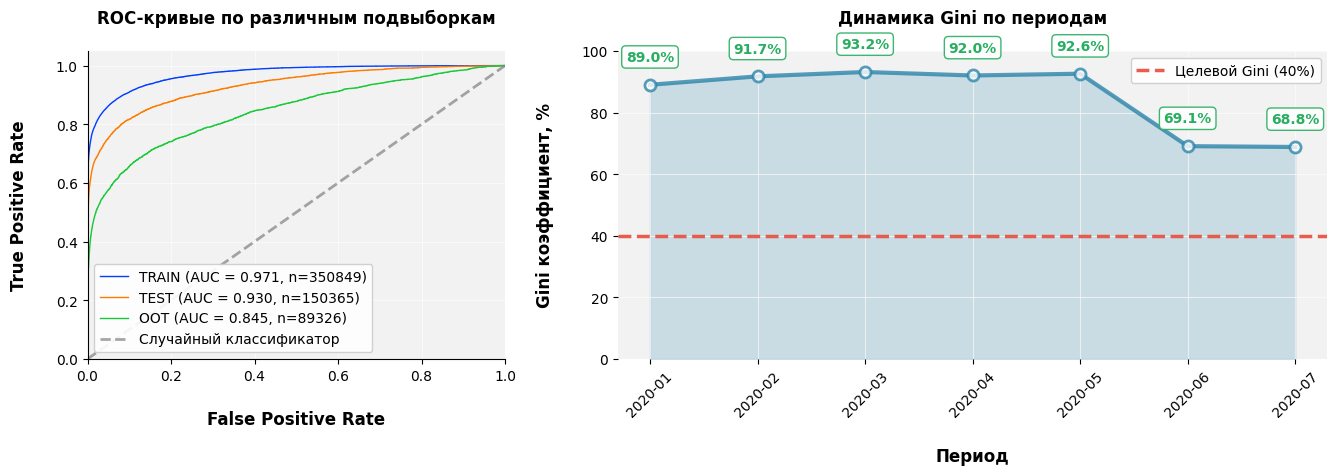

In [24]:
# Графики распределения таргета по выборкам
fig, axes = plt.subplots(1, 2, figsize=(16, 4), gridspec_kw={
                         'width_ratios': [1, 1.7]})
masks_dict = {'TRAIN': TRAIN_MASK, 'TEST': TEST_MASK, 'OOT': OOT_MASK}

ax = axes[0]
plot_roc_by_masks(data, TARGET, 'mlp_sklearn_preds', masks_dict,
                  figsize=(8, 4), palette='bright',
                  title='ROC-кривые по различным подвыборкам',
                  ax=ax)

ax = axes[1]
plot_gini_by_period_styled(metr_split.reset_index(), 'gini', DATE_MONTH,
                           figsize=(8, 4),
                           target_gini=40,
                           title='Динамика Gini по периодам',
                           ax=ax)

# Custom MLP 


In [28]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), NUM_FEATURES),
        ('cat', CatBoostEncoder(CatBoostEncoder(sigma=0.1, a=1            
    )), CAT_FEATURES),
    ], 
    remainder='passthrough'
)

X_train_processed = preprocessor.fit_transform(data.loc[TRAIN_MASK][FEATURES], data.loc[TRAIN_MASK][TARGET])
X_test_processed = preprocessor.transform(data.loc[TEST_MASK][FEATURES])
X_oot_processed = preprocessor.transform(data.loc[OOT_MASK][FEATURES])

In [23]:
from sklearn.utils.class_weight import compute_class_weight


In [34]:
model = Sequential()
model.add(Dense(512, activation='relu', input_shape=(X_train_processed.shape[1],)))
model.add(Dropout(0.2))
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(10, activation='tanh'))
model.add(Dense(2, activation='softmax'))
model.add(Dense(1, activation='sigmoid'))
model.summary()
model.compile(optimizer='rmsprop',
              loss='binary_crossentropy',
              metrics=[kr.metrics.AUC()])


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_40 (Dense)                │ (None, 512)            │       246,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_42 (Dense)                │ (None, 10)             │         1,290 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_43 (Dense)                │ (None, 2)              │            22 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_44 (Dense)                │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 313,763 (1.20 MB)

 Trainable params: 313,763 (1.20 MB)

 Non-trainable params: 0 (0.00 B)

In [35]:
model.fit(X_train_processed, data.loc[TRAIN_MASK][TARGET],
                    batch_size=500,
                    epochs=10,
                    verbose=1)

Epoch 1/10
702/702 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - auc: 0.6123 - loss: 0.2253
Epoch 2/10
702/702 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - auc: 0.7531 - loss: 0.1304
Epoch 3/10
702/702 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - auc: 0.8450 - loss: 0.1064
Epoch 4/10
702/702 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - auc: 0.8665 - loss: 0.0961
Epoch 5/10
702/702 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - auc: 0.8817 - loss: 0.0900
Epoch 6/10
702/702 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - auc: 0.8881 - loss: 0.0863
Epoch 7/10
702/702 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - auc: 0.8925 - loss: 0.0831
Epoch 8/10
702/702 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - auc: 0.8946 - loss: 0.0810
Epoch 9/10
702/702 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - auc: 0.8898 - loss: 0.0799
Epoch 10/10
702/702 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - auc: 0.8964 - loss: 0.0786


In [49]:
data.loc[TRAIN_MASK, "mlp_custom_preds"] = model.predict(X_train_processed).flatten()
data.loc[TEST_MASK, "mlp_custom_preds"] = model.predict(X_test_processed).flatten()
data.loc[OOT_MASK, "mlp_custom_preds"] = model.predict(X_oot_processed).flatten()

10965/10965 ━━━━━━━━━━━━━━━━━━━━ 3s 310us/step
4699/4699 ━━━━━━━━━━━━━━━━━━━━ 1s 308us/step
2792/2792 ━━━━━━━━━━━━━━━━━━━━ 1s 307us/step


In [51]:
metr_split = metrics_split(
    data=data.loc[DEV_MASK],
    target=TARGET,
    pred_cols='mlp_custom_preds',
    group_cols='sample_type',
    metr_calc=metr_calc,
    asc=False
)

style_metrics(metr_split, STYLE_CONFIG)

,level_1,roc_auc,gini,precision,recall,obs_cnt,target_cnt,DR
sample_type,,,,,,,,
TRAIN,mlp_custom_preds,92.3%,84.7%,85.0%,56.9%,350 849,12 276,3.5%
TEST,mlp_custom_preds,91.6%,83.3%,79.6%,54.2%,150 365,5 273,3.5%
OOT,mlp_custom_preds,86.3%,72.7%,68.0%,39.9%,89 326,3 114,3.5%


In [52]:
metr_split = metrics_split(
    data=data.loc[DEV_MASK],
    target=TARGET,
    pred_cols='mlp_custom_preds',
    group_cols=DATE_MONTH,
    metr_calc=metr_calc,
    asc=True
)

style_metrics(metr_split, STYLE_CONFIG)

,level_1,roc_auc,gini,precision,recall,obs_cnt,target_cnt,DR
date_month,,,,,,,,
2020-01,mlp_custom_preds,91.0%,82.0%,75.9%,53.8%,134 339,3 401,2.5%
2020-02,mlp_custom_preds,92.7%,85.3%,85.2%,57.6%,86 467,3 469,4.0%
2020-03,mlp_custom_preds,92.9%,85.7%,87.4%,61.2%,95 121,3 832,4.0%
2020-04,mlp_custom_preds,92.1%,84.1%,83.9%,52.8%,98 615,3 898,4.0%
2020-05,mlp_custom_preds,92.2%,84.3%,84.5%,54.5%,86 672,2 949,3.4%
2020-06,mlp_custom_preds,86.3%,72.5%,67.7%,39.8%,86 572,2 995,3.5%
2020-07,mlp_custom_preds,88.4%,76.8%,76.5%,43.7%,2 754,119,4.3%


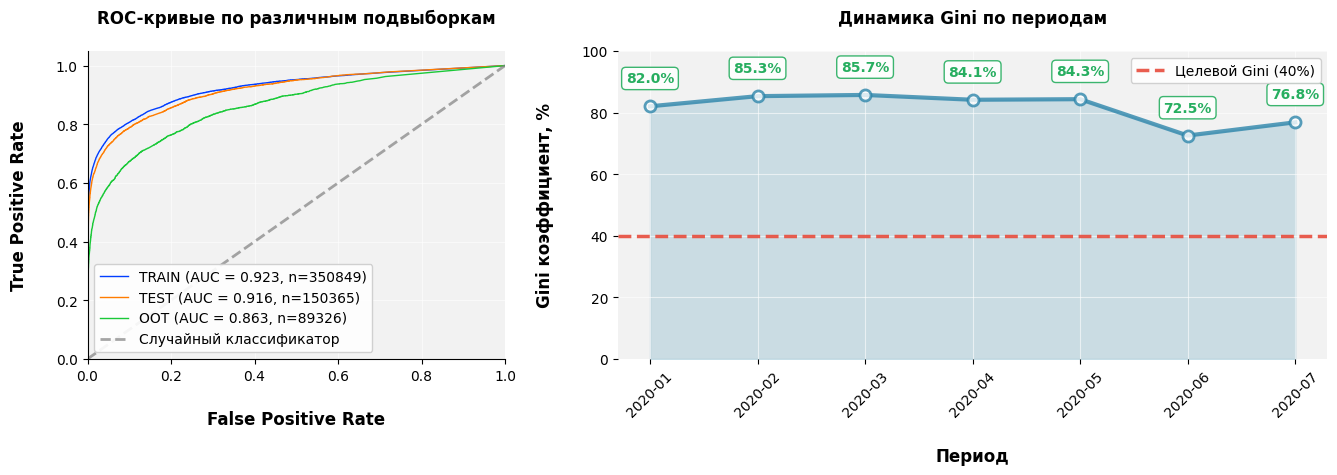

In [54]:
# Графики распределения таргета по выборкам
fig, axes = plt.subplots(1, 2, figsize=(16, 4), gridspec_kw={
                         'width_ratios': [1, 1.7]})
masks_dict = {'TRAIN': TRAIN_MASK, 'TEST': TEST_MASK, 'OOT': OOT_MASK}

ax = axes[0]
plot_roc_by_masks(data, TARGET, 'mlp_custom_preds', masks_dict,
                  figsize=(8, 4), palette='bright',
                  title='ROC-кривые по различным подвыборкам',
                  ax=ax)

ax = axes[1]
plot_gini_by_period_styled(metr_split.reset_index(), 'gini', DATE_MONTH,
                           figsize=(8, 4),
                           target_gini=40,
                           title='Динамика Gini по периодам',
                           ax=ax)